In [8]:
df=pd.read_csv(r'C:\Users\uwtuser\Downloads\Dataset_Prostate_Cancer (1).csv')

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
import seaborn as sns

In [9]:
df.head(5)

,id,diagnosis_result,radius,texture,perimeter,area,smoothness,compactness,symmetry,fractal_dimension
0,1,M,23,12,151,954,0.143,0.278,0.242,0.079
1,2,B,9,13,133,1326,0.143,0.079,0.181,0.057
2,3,M,21,27,130,1203,0.125,0.160,0.207,0.060
3,4,M,14,16,78,386,0.070,0.284,0.260,0.097
4,5,M,9,19,135,1297,0.141,0.133,0.181,0.059


In [10]:
df.isnull().sum()

id                   0
diagnosis_result     0
radius               0
texture              0
perimeter            0
area                 0
smoothness           0
compactness          0
symmetry             0
fractal_dimension    0
dtype: int64

In [11]:
# Identifying and inspecting categorical columns in the dataframe, particularly those with a manageable number of unique 
# categories, to check outliers, encoding types, data structure as well as balancing

categorical_col = [] # Initializes an empty list to store the names of the columns that are identified as 'categorical'.

for column in df.columns:  # Iterates through each column in the dataframe.
    
    if df[column].dtype==object and len(df[column].unique()) <=30:
    # Checks if the columns data type is 'object'(typically indicating a categorical variable) and if the number of unique 
    # values in that column is 30 or less than 30. Threshold can be as per data size.
        
        categorical_col.append(column) # If the conditions in the 'if' statement are met, it appends the column name to the 
        # 'categorical_col' list. 
        
        print(f"{column} : {df[column].value_counts()}") # Prints the name of the column and total number of values in the
                                                         # unique values.
        print(f"{column} : {df[column].unique()}") # Prints the name of the column and its unique values.
        print("====================================") # Prints a seperator line for clarity.
        

diagnosis_result : diagnosis_result
M    62
B    38
Name: count, dtype: int64
diagnosis_result : ['M' 'B']


In [12]:
# Identifying and inspecting columns in the dataframe, particularly those with a manageable number of unique 
# categories, to check outliers, encoding types, data structure as well as balancing

col = [] # Initializes an empty list to store the names of the columns that are identified as 'categorical'.

for column in df.columns:  # Iterates through each column in the dataframe.
    
    
    if len(df[column].unique()) <= 500: # Checks if the columns data type is 'object'(typically 
        # indicating a categorical variable) and if the number of unique values in that column is 30 or less than 30. 
        # Threshold can be as per data size.
        
        col.append(column) # If the conditions in the 'if' statement are met, it appends the column name to the 
        # 'categorical_col' list. 
        
        print(f"{column} : {df[column].value_counts()}") # Prints the name of the column and total number of values in the
                                                         # unique values.
        print(f"{column} : {df[column].unique()}") # Prints the name of the column and its unique values.
        print("====================================") # Prints a seperator line for clarity.
       

id : id
1      1
2      1
3      1
4      1
5      1
      ..
96     1
97     1
98     1
99     1
100    1
Name: count, Length: 100, dtype: int64
id : [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100]
diagnosis_result : diagnosis_result
M    62
B    38
Name: count, dtype: int64
diagnosis_result : ['M' 'B']
radius : radius
10    11
19     9
11     8
16     8
22     7
17     6
21     6
25     6
20     6
18     6
14     5
23     5
12     5
15     5
9      4
24     3
Name: count, dtype: int64
radius : [23  9 21 14 25 16 15 19 24 17 12 22 10 20 11 18]
texture : texture
15    9
21    9
14    8
13    8
11    8
12    7
27    7
18    7
26    7


In [13]:
# Doing Label Encoding for column 'diagnosis_result'

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

result =  df['diagnosis_result']

result1= le.fit_transform(result)

In [14]:
# Making a Data Frame of 'diagnosis_result' so that we can concatenate it with the data frame df

resultdf =  pd.DataFrame(result1 , columns = ['result'])
resultdf

,result
0,1
1,0
2,1
3,1
4,1
...,...
95,1
96,0
97,0
98,0


In [15]:
# Concatenate result in df

df = pd.concat([df , resultdf] , axis =1 )
df.head()

,id,diagnosis_result,radius,texture,perimeter,area,smoothness,compactness,symmetry,fractal_dimension,result
0,1,M,23,12,151,954,0.143,0.278,0.242,0.079,1
1,2,B,9,13,133,1326,0.143,0.079,0.181,0.057,0
2,3,M,21,27,130,1203,0.125,0.160,0.207,0.060,1
3,4,M,14,16,78,386,0.070,0.284,0.260,0.097,1
4,5,M,9,19,135,1297,0.141,0.133,0.181,0.059,1


In [16]:
# Remove variable 'id' which does not impact on the 'result', and 'diagnosis_result'

df.drop(['id','diagnosis_result'], axis=1, inplace = True)

In [17]:
df

,radius,texture,perimeter,area,smoothness,compactness,symmetry,fractal_dimension,result
0,23,12,151,954,0.143,0.278,0.242,0.079,1
1,9,13,133,1326,0.143,0.079,0.181,0.057,0
2,21,27,130,1203,0.125,0.160,0.207,0.060,1
3,14,16,78,386,0.070,0.284,0.260,0.097,1
4,9,19,135,1297,0.141,0.133,0.181,0.059,1
...,...,...,...,...,...,...,...,...,...
95,23,16,132,1264,0.091,0.131,0.210,0.056,1
96,22,14,78,451,0.105,0.071,0.190,0.066,0
97,19,27,62,295,0.102,0.053,0.135,0.069,0
98,21,24,74,413,0.090,0.075,0.162,0.066,0


In [18]:
# Dividing the data set in x and y

y = df.result.values
x = df.drop(['result'], axis = 1).values

In [19]:
# Normalize the data- feature scaling

import numpy as np
x_norm = (x - np.min(x)) / (np.max(x) - np.min(x))

In [20]:
# Train Test Split

x_train, x_test, y_train, y_test = train_test_split(x_norm,y,test_size = 0.3,random_state=0)

In [22]:
!pip install xgboost

   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   --------- ------------------------------ 17.3/72.0 MB 92.6 MB/s eta 0:00:01
   ------------- -------------------------- 24.1/72.0 MB 59.6 MB/s eta 0:00:01
   ----------------- ---------------------- 31.7/72.0 MB 52.1 MB/s eta 0:00:01
   ---------------------- ----------------- 40.1/72.0 MB 48.9 MB/s eta 0:00:01
   -------------------------- ------------- 47.7/72.0 MB 46.2 MB/s eta 0:00:01
   ------------------------------ --------- 55.3/72.0 MB 44.9 MB/s eta 0:00:01
   ---------------------------------- ----- 61.6/72.0 MB 42.3 MB/s eta 0:00:01
   ------------------------------------- -- 67.4/72.0 MB 40.6 MB/s eta 0:00:01
   ---------------------------------------  71.8/72.0 MB 40.9 MB/s eta 0:00:01
   ---------------------------------------- 72.0/72.0 MB 35.1 MB/s eta 0:00:00


In [25]:
# Now we will fit few models together using a loop

# importing necessary libraries

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier  
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [26]:
# Create a list of models 

models = []

models.append(('Logistic Regression' ,LogisticRegression(random_state=42)))
models.append(('CART', DecisionTreeClassifier(random_state = 42)))
models.append(('Random Forest', RandomForestClassifier(random_state = 42)))
models.append(('SVM', SVC(gamma='auto', random_state = 42)))
models.append(('KNN', KNeighborsClassifier()))
models.append(('Naive bayes', GaussianNB()))

# The parameter 'gamma' is a regularization parameter that influences the shape of the decision boundary. 
# A small gamma means large similarity radius (means larger marginal distance) leading to a smoother decision boundary.
# A large gamma makes the decision boundary more dependent on the training data, potentially resulting in a more complex
# decision boundary that can cause overfitting. (which might fit the training data well,but generalize poorly to new data)

results = []

names = []

In [27]:
from sklearn import metrics
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, precision_score, recall_score, f1_score

In [28]:
# Fitting all the models and calculate accuracy (doing predictions first) for all the models in a for loop

for name, model in models: 
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    print("{} : {}".format(name,accuracy))

Logistic Regression : 0.8666666666666667
CART : 0.7
Random Forest : 0.8666666666666667
SVM : 0.8
KNN : 0.8666666666666667
Naive bayes : 0.7666666666666667


In [29]:
# Since Logistic Regression, Random Forest and KNN are giving same accuracies, going ahead with hyperparameter tuning, cross 
# validation of these models to see if it increases the model accuracies further.

In [30]:
# ******************************************* Logistic Regression **********************************************************

In [31]:
# Applying Logistic Regression Without Cross Validation

lr = LogisticRegression(solver = 'liblinear', random_state = 1) 

lr.fit(x_train, y_train)

LogisticRegression(random_state=1, solver='liblinear')

In [32]:
lr.score(x_train,y_train)

0.7714285714285715

In [33]:
lr.score(x_test,y_test)

0.8666666666666667

In [34]:
y_pred_lr = lr.predict(x_test)


In [35]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

In [36]:
accuracy_lr

# Accuracy after applying LR with solver 'liblinear' remains the same-0.8666666666666667 as the default accuracy-0.8666666666666667

0.8666666666666667

In [37]:
# Applying Logistic with hyperparameter tuning

# Creating a pipeline with StandardScaler and logistic regression

from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('scaler', StandardScaler()), ('clf', LogisticRegression())
])

In [38]:
# Defining the parameter grid for GridSearchCV

param_grid = {
    'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization parameter
    'clf__penalty': ['l1', 'l2'],  # Penalty term for Lasso (L1) and Ridge (L2)
    'clf__solver': ['liblinear', 'saga'],  # Solver algorithm for logistic regression
}

# solver = 'liblinear': The 'Solver' parameter specifies the algorithm to use for optimization. In this case, 'liblinear' solver
# is well suited for small to medium sized data sets and is efficient for binary and multiclass (variable having more no of 
# categories other than 0 and 1) logistic regression problems.


In [39]:
# Perform GridSearchCV
# Using GridSearch to perform a search over the 'param_grid' for the best set of hyperparameters.
# cross validation on Logistic Regression
# We can try RandomSearchCV instead of GridSearchCV as well.

from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid_search.fit(x_train, y_train)

C:\Users\uwtuser\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\uwtuser\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\uwtuser\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\uwtuser\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\uwtuser\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\uwtuser\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: T

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('clf', LogisticRegression())]),
             param_grid={'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'clf__penalty': ['l1', 'l2'],
                         'clf__solver': ['liblinear', 'saga']},
             scoring='accuracy')

In [40]:
# Finding the best parameters from cross validated Bernoulli Naive Bayes model

print("Best parameters: ", grid_search.best_params_)

Best parameters:  {'clf__C': 0.1, 'clf__penalty': 'l1', 'clf__solver': 'saga'}


In [41]:
# The best accuracy score for Logistic Regression with CV for best parameters alpha=0.1 is found below:

grid_search.best_score_

# Accuracy score is getting decreased-0.8285714285714285 after applying Logistic Regression hyper parameter tuning.
# Default accuracy was: 0.8666666666666667

np.float64(0.8285714285714285)

In [42]:
# Trying by changing the value of cv folds and to see if accuracy increases further

# With cv=25

grid_search = GridSearchCV(pipeline, param_grid, cv=25, scoring='accuracy')
grid_search.fit(x_train, y_train)

C:\Users\uwtuser\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\uwtuser\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\uwtuser\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\uwtuser\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\uwtuser\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\uwtuser\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: T

GridSearchCV(cv=25,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('clf', LogisticRegression())]),
             param_grid={'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'clf__penalty': ['l1', 'l2'],
                         'clf__solver': ['liblinear', 'saga']},
             scoring='accuracy')

In [43]:
# Finding the best parameters from cross validated Bernoulli Naive Bayes model

print("Best parameters: ", grid_search.best_params_)

Best parameters:  {'clf__C': 0.1, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}


In [44]:
# The best accuracy score for Logistic Regression with CV for best parameters alpha=0.1 is found below:

grid_search.best_score_

# Accuracy score is not increasing after changing cv folds.
# Default accuracy was: 0.8666666666666667, accuracy after changing the cv fold from 5 to 25: 0.7933333333333333

np.float64(0.7933333333333333)

In [45]:
#***********************************************RANDOM FOREST*********************************************************

In [46]:
# Trying with hyperparameter tuning of RF

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators = 50, random_state = 1) 

# n_estimators: How many Decision Trees this Random Forest model will include

rf.fit(x_train, y_train)

RandomForestClassifier(n_estimators=50, random_state=1)

In [47]:
train_score_rf = rf.score(x_train,y_train)
test_score_rf = rf.score(x_test,y_test)

In [48]:
train_score_rf

1.0

In [49]:
test_score_rf

# There is overfitting.

0.8666666666666667

In [50]:
# Checking with n_estimator- 1000

rf1 = RandomForestClassifier(n_estimators = 1000, random_state = 1) 
rf1.fit(x_train, y_train)

RandomForestClassifier(n_estimators=1000, random_state=1)

In [51]:
train_score_rf1 = rf1.score(x_train,y_train)
test_score_rf1 = rf1.score(x_test,y_test)

In [52]:
train_score_rf1

1.0

In [53]:
test_score_rf1

# There is no change in train test score after increasing the value of n_estimator from 50 to 1000. There is overfitting.

0.8666666666666667

In [54]:
# Applying hyperparameter tuning for Random Forest

# Create a classifier for the RF

rf2 = RandomForestClassifier()

In [55]:
# Define the hyperparameters to search through

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


In [56]:
# Create a GridSearchCV object with cross-validation

from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(rf2, param_grid, cv=5, scoring='accuracy')

# Fit the model to the data
grid_search.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [57]:
# Get the best parameters

print("Best parameters: ", grid_search.best_params_)

Best parameters:  {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [58]:
# Get the best score from the tuned parameters

grid_search.best_score_


np.float64(0.8)

In [59]:
# Checking the tuned accuracy score:

# The 'grid_search.best_score_' attribute represents the mean cross validated score of the best estimator. This score is 
# obtained by cross validating the model with the best hyperparameters on the training data during the grid search/random search.
# This can be considered as an estimate of the model's average performance during cross validation on the training data.

# On the other hand, tuned accuracy is the accuracy computed on the seperate test set. 

# The 'grid_search.best_score_' is likely to be different in most cases from tuned accuracy. The grid search aims to find 
# hyperparameters that perform well on average across multiple folds of the training data. Whereas, tuned accuracy evaluates
# the model's performance on a distinct test set. 

# The primary goal is to ensure that the model generalizes well to unseen data which is represented by tuned accuracy. 

# Case 1: If the tuned accuracy is high, and the model performs well on test sets, it suggests that the selected hyperparameters
# generalize well to new unseen data. 

# Case 2: If the gridsearch.best_score_ is higher than tuned accuracy, it indicates that the model's performance as estimated
# by cross validation on the training data is higher on average compared to it's performance on separate test data. 

# Possible reasons for case 2 are: 
# i. Small test data: The test data might be relatively small, leading to more variability in performance metrics.
# Cross validation by averaging over multiple folds provides a more stable estimate of the model's performance.

# ii. Data splitting variability: The random splitting of data into training and testing datasets can introduce variability.
# The specific splits used for tuned accuracy might result in a test set that is more challenging for the model compared
# to the average difficulty observed during cross validation.

# iii. Overfitting to the training data: The model might be overfitting to the traing data and the specific hyperparameters 
# tuned during grid search might be more prone to overfitting. Cross validation gives more conservative estimate (balanced)
# as it evaluates the model on different subsets of the training data.

# Conclusion: While it is important to consider the cross validation score (grid_search.best_score_) as an indication of
# how well the model generalizes to new data, the ultimate measure of performance is how well the model performs on truely
# unseen data which is represented by tuned accuracy. 

# In case the difference is substantial (difference between grid and tuned scores is more), we need to potentially revisit
# the hyperparameter tuning process, or consider ways to increase the size or diversity of the test data (means changing the cv
# folds or value of random state).

In [60]:
# Create a Random Forest classifier with the best parameters- only if the best accuracy score from the tuned parameters is 
# better than default parameters. 

# Tuned accuracy score-80% is less than accuracy score with default accuracy score- 86%, hence this step is not required here.

In [61]:
# Checking if the best score increases after changing the parameter values in 'param_grid'

# Create a classifier for the RF

rf3 = RandomForestClassifier()

In [62]:
# Define the hyperparameters to search through

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 15, 25],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [3, 5, 7]
}


In [63]:
# Create a GridSearchCV object with cross-validation

from sklearn.model_selection import GridSearchCV

grid_search2 = GridSearchCV(rf3, param_grid, cv=5, scoring='accuracy')

# Fit the model to the data
grid_search2.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [None, 15, 25],
                         'min_samples_leaf': [3, 5, 7],
                         'min_samples_split': [5, 10, 15],
                         'n_estimators': [100, 300, 500]},
             scoring='accuracy')

In [64]:
# Get the best parameters

print("Best parameters: ", grid_search.best_params_)

Best parameters:  {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [65]:
# Get the best score from the tuned parameters

grid_search.best_score_

# Even after changing the parameters in 'param_grid', the accuracy score is not improving.

np.float64(0.8)

In [66]:
# Get the best model with tuned hyperparametrs
# Creating instance for best estimator

best_model = grid_search.best_estimator_

In [67]:
# Finding predictions on test data using the best model

y_pred_rf2_best = best_model.predict(x_test)

In [68]:
# Accuracy score

tuned_rf2_best_acc = accuracy_score(y_test, y_pred_rf2_best)

In [69]:
tuned_rf2_best_acc

0.9333333333333333

In [70]:
# Check for overfitting

grid_search.score(x_train, y_train)

0.9714285714285714

In [71]:
grid_search.score(x_test, y_test)

# There is no overfitting and accuracy is maximized.

0.9333333333333333

In [72]:
#*************************************************** KNN *********************************************************************

In [73]:
# Checking with KNN hyperparameter tuning

from sklearn.neighbors import KNeighborsClassifier
neighbors = np.arange(1,9)
neighbors

# Applying a range of neighbours.

array([1, 2, 3, 4, 5, 6, 7, 8])

In [74]:
# Set up arrays to store train and test accuracies for different values of K.

train_accuracy_knn = np.empty(len(neighbors))
test_accuracy_knn = np.empty(len(neighbors))

In [75]:
# Generating a for loop with the list of neighbours to do the train data fit for each of the K values and find out their
# train and test accuracies.

for i,k in enumerate(neighbors):   
    
    # Enumerate: We are using a loop to iterate over different values of k for the number of neighbours in a K nearest Neighbors 
    # classifier.
    
    knn = KNeighborsClassifier(n_neighbors=k)
    
    # Using scikitlearn's KNeighborsClassifier, we are training the classifier with different values of k and evaluating
    # it's performance.
    
    knn.fit(x_train, y_train)
    
    
    train_accuracy_knn[i] = knn.score(x_train, y_train)
    
   
    test_accuracy_knn[i] = knn.score(x_test, y_test)

In [76]:
train_accuracy_knn

array([1.        , 0.84285714, 0.85714286, 0.8       , 0.82857143,
       0.81428571, 0.81428571, 0.81428571])

In [77]:
test_accuracy_knn

array([0.66666667, 0.7       , 0.83333333, 0.83333333, 0.86666667,
       0.83333333, 0.83333333, 0.83333333])

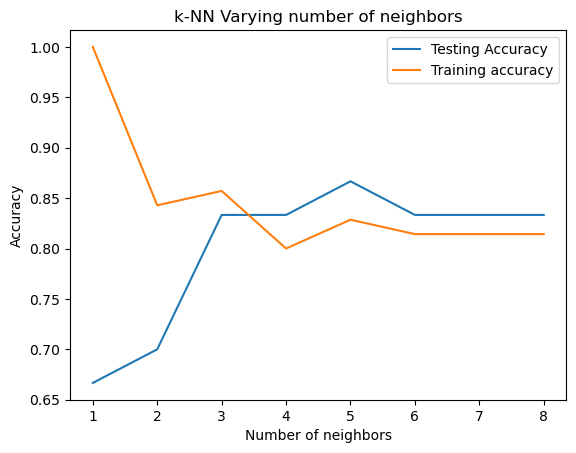

In [78]:
# Checking for the stable train and test accuracy scores with the help of plot

plt.title('k-NN Varying number of neighbors')
plt.plot(neighbors, test_accuracy_knn, label='Testing Accuracy')
plt.plot(neighbors, train_accuracy_knn, label='Training accuracy')
plt.legend()
plt.xlabel('Number of neighbors')
plt.ylabel('Accuracy')
plt.show()

# Conclusion: By optimizing the stabilized train and test score (ensuring no underfitting as well as overfitting), and 
# maximizing the accuracy score, we get k = 5 as the best KNN parameter. 

In [79]:
# Fitting KNN model with k = 5 to get the final best accuracy.

knn = KNeighborsClassifier(n_neighbors=5)


In [80]:
knn.fit(x_train, y_train)

KNeighborsClassifier()

In [81]:
train_accuracy_knn_k5 = knn.score(x_train, y_train)
    
test_accuracy_knn_k5 = knn.score(x_test, y_test)

In [82]:
train_accuracy_knn_k5, test_accuracy_knn_k5

(0.8285714285714286, 0.8666666666666667)

In [83]:
y_pred_knn_k5 = knn.predict(x_test)

In [84]:
# Checking evaluation metrics for knn with k =6

accuracy_knn_k5 = accuracy_score(y_test, y_pred_knn_k5)
accuracy_knn_k5

# Conclusion: Accuracy score after applying KNN hyper parameter tuning remains same-0.8666666666666667 as the default accuracy
# score with KNN-0.8666666666666667

0.8666666666666667

In [85]:
# ************************* Classification report and Confusion matrix for LR, RF and KNN ************************

In [86]:
# Classification report for Logistic Regression

print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

           0       0.75      0.50      0.60         6
           1       0.88      0.96      0.92        24

    accuracy                           0.87        30
   macro avg       0.82      0.73      0.76        30
weighted avg       0.86      0.87      0.86        30



In [87]:
# Confusion matrix for Logistic Regression

confusion_matrix(y_test,y_pred_lr)
pd.crosstab(y_test,y_pred_lr,rownames = ['actual'],colnames = ['predicted'], margins = True)

predicted,0,1,All
actual,,,
0,3,3,6
1,1,23,24
All,4,26,30


In [88]:
# Classification report for KNN with k=5:

print(classification_report(y_test,y_pred_knn_k5))

              precision    recall  f1-score   support

           0       0.62      0.83      0.71         6
           1       0.95      0.88      0.91        24

    accuracy                           0.87        30
   macro avg       0.79      0.85      0.81        30
weighted avg       0.89      0.87      0.87        30



In [89]:
# Confusion matrix for KNN with k=5:

confusion_matrix(y_test,y_pred_knn_k5)
pd.crosstab(y_test,y_pred_knn_k5,rownames = ['actual'],colnames = ['predicted'], margins = True)

predicted,0,1,All
actual,,,
0,5,1,6
1,3,21,24
All,8,22,30


In [90]:
# Classification report for Random Forest with tuned parameters:

print(classification_report(y_test,y_pred_rf2_best))

              precision    recall  f1-score   support

           0       0.83      0.83      0.83         6
           1       0.96      0.96      0.96        24

    accuracy                           0.93        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.93      0.93      0.93        30



In [91]:
# Confusion matrix for KNN with k=5:

confusion_matrix(y_test,y_pred_rf2_best)
pd.crosstab(y_test,y_pred_rf2_best,rownames = ['actual'],colnames = ['predicted'], margins = True)

predicted,0,1,All
actual,,,
0,5,1,6
1,1,23,24
All,6,24,30


In [92]:
# Final Conclusion: 

# Initial accuracy scores of all models:

# Logistic Regression : 0.8666666666666667
# CART : 0.7
# Random Forest : 0.8666666666666667
# SVM : 0.8
# KNN : 0.8666666666666667
# Naive bayes : 0.7666666666666667

# Since Logistic Regression, Random Forest and KNN were giving good accuracies, I applied hyperparameter tuning for these models to check if the accuracy score increases further.
# However, accuracies of Logistic Regression and KNN did not increase even after applying tuned parameters. 

# For Random Forest, I applied hyperparameter tuning, and the tuned accuracy score using the best parameters is 93.33%, which 
# is greater than the default accuracy score of Random Forest, which was 86%.

# As per the classification report, the number of False Positives and False Negatives using Random Forest are the minimum-1. 
# Also, the F1 score, model accuracy with Random Forest hyperparameter tuning is the best among all 3 models.

# Hence, we can conclude that Random Forest is the best model. We can use 'y_pred_rf2_best' for prediction.

In [93]:
y_pred_rf2_best

array([1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 1, 1, 1, 1])